In [45]:
import numpy as np
import scipy as sp
import handcalcs.render

import matplotlib.pyplot as plt
from cycler import cycler
import palettable.wesanderson as wa
plt.rcParams['axes.prop_cycle'] = cycler(color=wa.IsleOfDogs2_6.mpl_colors)

# Reševanje sistema linearnih enačb - numerični pristop

V vaji bomo analizirali __kinematično stabilnost__ ravninskega okvirja. Kinematična stabilnost se pogosto preverja z oblikovanjem __sistema linarnih enačb__, s katerimi opišemo ravnotežne pogoje in geometrijske povezave. 

Poglejmo dva primera prikazana na sliki:
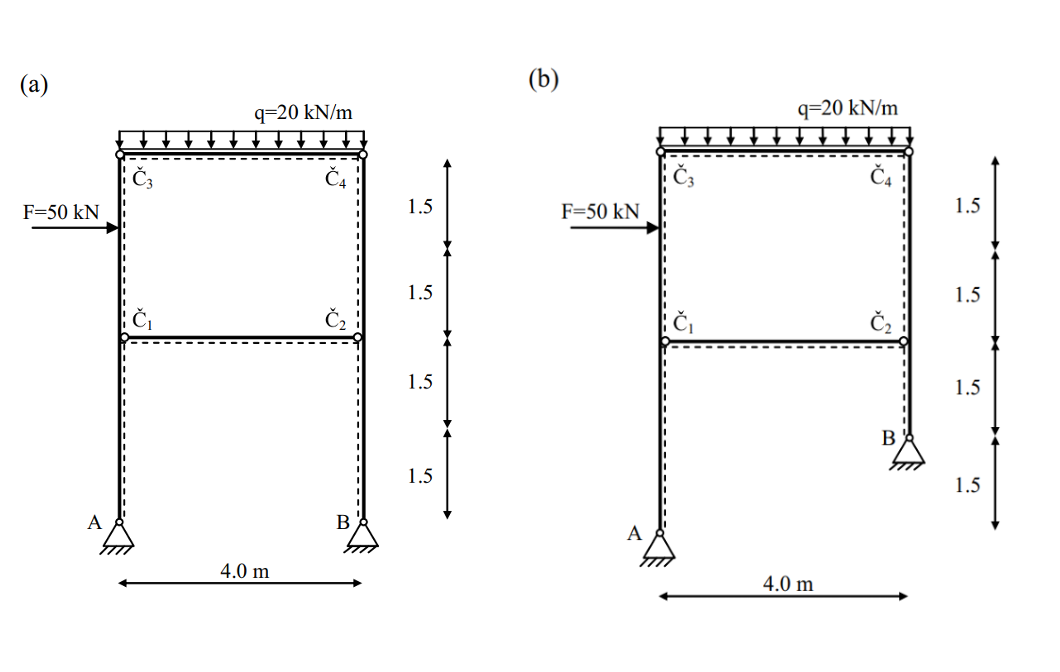
referenca: (B. Macuh, S. Škrabl, Statika, vaje, Maribor, 2013)

Za primer lahko zapišemo ravnotežne enačbe:

I 
$$X_A - H_{C1} + F - H_{C3} = 0$$
$$Y_A - V_{C1} - V_{C3} = 0$$
$$6X_A - 3H_{C1} + 1.5F = 0$$

II 
$$H_{C1} - H_{C2} = 0$$
$$V_{C1} + V_{C2} = 0$$
$$-4V_{C1} = 0$$

III 
$$X_B + H_{C2} + H_{C4} = 0$$
$$Y_B - V_{C2} - V_{C4} = 0$$
$$6X_B + 3H_{C2} = 0$$

IV 
$$H_{C3} - H_{C4} = 0$$
$$V_{C3} - 4q + V_{C4} = 0$$
$$-4V_{C3} + 2\cdot4q = 0$$

 \
Ker gre za linearne odnose, problem lahko modeliramo z zapisom v matrični obliki:
$$Ax = b$$

Kjer je $A$ matrika koeficientov sistema in predstavlja povezave in ravnotežne pogoje. Vektor $x$ predstavlja neznane reakcije in druge neznane lastnosti sistema, v našem primeru so to vezne sile v členkih. Vektor $b$ pa je vektor znanih vrednosti, npr. obremenitve, imenujemo ga vektor konstant.

Za reševanje sistema z numeričnimi metodami bomo uporabili knjižnico __SciPy__ vsebuje učinkovite metode za linearno algebro. Metode nam omogočajo:
- reševanje sistema enačb (`scipy.linalg.solve()`)
- izračun ranga matrike (`scipy.linalg.matrix_rank()`)
- izračun determinante matrike (`scipy.linalg.det()`)

### Rešitev

#### Primer a)
Zapišimo matriko A. Iz enačb vidimo, da potrebujemo matriko 12x12, ki pa je po večini prazna (členi so enaki 0).
Zato ni smiselno celotne matrike sestaviti iz seznamov. Namesto tega bomo pripravili matriko 12x12 samih ničel. Nato pa bomo vpisali koeficiente, ki so različni od 0.

In [2]:
A = np.zeros(shape=(12,12))
A

array([[0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]])

V vseh enačbah moramo spremenljivke "poravnati" glede na stolpec. V vseh enačbah bomo $X_A$ zapisali s koeficientom $a_{i,1}\cdot X_A$, kar pomeni, da bomo koeficiente s katerimi množimo $X_A$ zapisali v prvi stolpec matrike $A$, kot si enačbe sledijo po vrsticah.  

Uporabili bomo sledeči vrstni red:
$$X_A, Y_A, X_B, Y_B, H_{C1}, V_{C1}, H_{C2}, V_{C2}, H_{C3}, V_{C3}, H_{C4}, V_{C4}$$

In [46]:
A[0,0], A[0,4], A[0,8] = 1, -1, -1
A[1,1], A[1,5], A[1,9] = 1, -1, -1
A[2,0], A[2,4] = 6, -3
A[3,4], A[3,6] = 1, -1
A[4,5], A[4,7] = 1, 1
A[5,5] = -4
A[6,2], A[6,6], A[6,10] = 1, 1, 1
A[7,3], A[7,7], A[7,11] = 1, -1, -1
A[8,2], A[8,6] = 6, 3
A[9,8], A[9,10] = 1, -1
A[10,9], A[10,11] = 1, 1
A[11,9] = -4

A

array([[ 1.,  0.,  0.,  0., -1.,  0.,  0.,  0., -1.,  0.,  0.,  0.],
       [ 0.,  1.,  0.,  0.,  0., -1.,  0.,  0.,  0., -1.,  0.,  0.],
       [ 6.,  0.,  0.,  0., -3.,  0.,  0.,  0.,  0.,  0.,  0.,  0.],
       [ 0.,  0.,  0.,  0.,  1.,  0., -1.,  0.,  0.,  0.,  0.,  0.],
       [ 0.,  0.,  0.,  0.,  0.,  1.,  0.,  1.,  0.,  0.,  0.,  0.],
       [ 0.,  0.,  0.,  0.,  0., -4.,  0.,  0.,  0.,  0.,  0.,  0.],
       [ 0.,  0.,  1.,  0.,  0.,  0.,  1.,  0.,  0.,  0.,  1.,  0.],
       [ 0.,  0.,  0.,  1.,  0.,  0.,  0., -1.,  0.,  0.,  0., -1.],
       [ 0.,  0.,  6.,  0.,  0.,  0.,  3.,  0.,  0.,  0.,  0.,  0.],
       [ 0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  1.,  0., -1.,  0.],
       [ 0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  1.,  0.,  1.],
       [ 0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0., -4.,  0.,  0.]])

Zapišemo vektor konstant $b$. Pri tem določimo še konstanti F in q.

In [5]:
F = 50
q = 20
b = np.array([-F, 0, -1.5*F, 0, 0, 0, 0, 0, 0, 0, 4*q, -2*4*q])
b

array([ -50.,    0.,  -75.,    0.,    0.,    0.,    0.,    0.,    0.,
          0.,   80., -160.])

Preverimo rang matrike koeficientov (uporabimo NumPy) ter determinanto.

In [6]:
sp.linalg.det(A)

np.float64(0.0)

In [7]:
np.linalg.matrix_rank(A)

np.int64(11)

Oba testa vrneta rezultat, ki kaže na singularnost matrike koeficientov. Determinanta je enaka 0. To pomeni, da sistem ni kinematično stabilen. Rang matrike 11 kaže, da imamo le 11 linearno nedovisnih vrstic matrike, kar pomeni, da imamo dejansko sistem 11 enačb (ena se da izraziti z linearno kombinacijo ostalih) pri čemer pa iščemo 12 neznank.

#### Primer b)

Poglejmo, če premik podpore B navzgor kaj spremeni?

Premik ima učinek na upogibni moment v členku 4, ki ga ustvarja horizontalna komponenta reakcije v podpori B. Sprememba se ne odrazi v nobeni drugi enačbi. Zato je porebno spremeniti le en člen matrike koeficientov $A$, in sicer je to člen, ki se nanaša na $X_B$ (stolpec z indeksom 2) v enačbi 9 (vrstica z indeksom 8).

In [8]:
A[8, 2] = 4.5

Poskusimo sedaj izračunati determinanto in rang matrike $A$.

In [9]:
sp.linalg.det(A)

np.float64(-72.0)

In [10]:
np.linalg.matrix_rank(A)

np.int64(12)

Vidimo, da je sistem sedaj kinematično stabilen in je reššljiv tudi sistem linearnih enačb.

Izračunajmo rešitev sistema enačb in določimo vrednosti sil.

In [11]:
X_A, Y_A, X_B, Y_B, H_C1, V_C1, H_C2, V_C2, H_C3, V_C3, H_C4, V_C4 = sp.linalg.solve(A, b)

In [12]:
%%render 1 params
X_A
Y_A
X_B 
Y_B 
H_C1 
V_C1 
H_C2 
V_C2 
H_C3 
V_C3 
H_C4 
V_C4

<IPython.core.display.Latex object>

## Analiza odziva sistema

### Sprememba višine podpore B

Kaj se v sistemu dogaja, ko spreminjamo višino podpore B? 

Označimo višino podpore $h_b$ in preverimo reakcije in sile v člankih za $h_b$ v razponu $0 \leq h_b \leq 1.5$. Odziv bomo preverili za vsaki milimeter, torej bomo razpon razdelili na 1500 delov, kar pomeni 1501 korak. 

In [23]:
h_b = np.linspace(0, 1.5, 1501)
h_b[1:30]

array([0.001, 0.002, 0.003, 0.004, 0.005, 0.006, 0.007, 0.008, 0.009,
       0.01 , 0.011, 0.012, 0.013, 0.014, 0.015, 0.016, 0.017, 0.018,
       0.019, 0.02 , 0.021, 0.022, 0.023, 0.024, 0.025, 0.026, 0.027,
       0.028, 0.029])

Za vsak $a_{8,2}=4.5+h_b$ rešimo sistem $Ax=b$. Pri tem moramo preverjati ali je sistem rešljiv, saj nam v nasprotnem primeru funkcija `solve()` javi napako 'Matrix is singular'. Vektorje rešitev, ki jih vrne funkcija `solve()` bomo zapisali v seznam vseh rešitev.

In [37]:
resitve = []
for h in h_b:
    A[8,2] = 4.5 + h
    if sp.linalg.det(A) != 0:
        resitve.append(sp.linalg.solve(A, b))
    else:
        resitve.append([np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan ])

resitve = np.array(resitve)
resitve[:5,:]  # prvih 5 rešitev

array([[-100.        , -160.        ,  150.        ,  480.        ,
        -225.        ,   -0.        , -225.        ,    0.        ,
          75.        , -160.        ,   75.        ,  480.        ],
       [-100.10006671, -160.        ,  150.10006671,  480.        ,
        -225.20013342,   -0.        , -225.20013342,    0.        ,
          75.10006671, -160.        ,   75.10006671,  480.        ],
       [-100.20026702, -160.        ,  150.20026702,  480.        ,
        -225.40053405,   -0.        , -225.40053405,    0.        ,
          75.20026702, -160.        ,   75.20026702,  480.        ],
       [-100.3006012 , -160.        ,  150.3006012 ,  480.        ,
        -225.6012024 ,   -0.        , -225.6012024 ,    0.        ,
          75.3006012 , -160.        ,   75.3006012 ,  480.        ],
       [-100.40106952, -160.        ,  150.40106952,  480.        ,
        -225.80213904,   -0.        , -225.80213904,    0.        ,
          75.40106952, -160.        ,   75.4

Matrika rešitev je zapisana tako, da vsaka vrstica predstavlja eno rešitev sistema in teh vrstic je 1501.

Za vsako spremenljivko lahko sedaj narišemo graf odvisnosti med izbrano spremenljivko in $h_b$. Pri risanju grafa potrebujemo seznam vseh vrednosti $h_b$, ki ga že imamo. Potrebujemo pa še seznam vseh rešitev za izbrano spremenljivko. Če matriko rešitev transponiramo, bomo dobili matriko z 12 vrsticami in 1501 stolpcem. Pri tem bo vsaka vrstica vsebovala nabor vseh rešitev ene spremenljivke. 

In [38]:
X = resitve.T
X[:, 0:4]  #prve 4 rešitve za vsako spremenljivko

array([[-100.        , -100.10006671, -100.20026702, -100.3006012 ],
       [-160.        , -160.        , -160.        , -160.        ],
       [ 150.        ,  150.10006671,  150.20026702,  150.3006012 ],
       [ 480.        ,  480.        ,  480.        ,  480.        ],
       [-225.        , -225.20013342, -225.40053405, -225.6012024 ],
       [  -0.        ,   -0.        ,   -0.        ,   -0.        ],
       [-225.        , -225.20013342, -225.40053405, -225.6012024 ],
       [   0.        ,    0.        ,    0.        ,    0.        ],
       [  75.        ,   75.10006671,   75.20026702,   75.3006012 ],
       [-160.        , -160.        , -160.        , -160.        ],
       [  75.        ,   75.10006671,   75.20026702,   75.3006012 ],
       [ 480.        ,  480.        ,  480.        ,  480.        ]])

Narišimo grafe poteka vseh spremenljivk. 

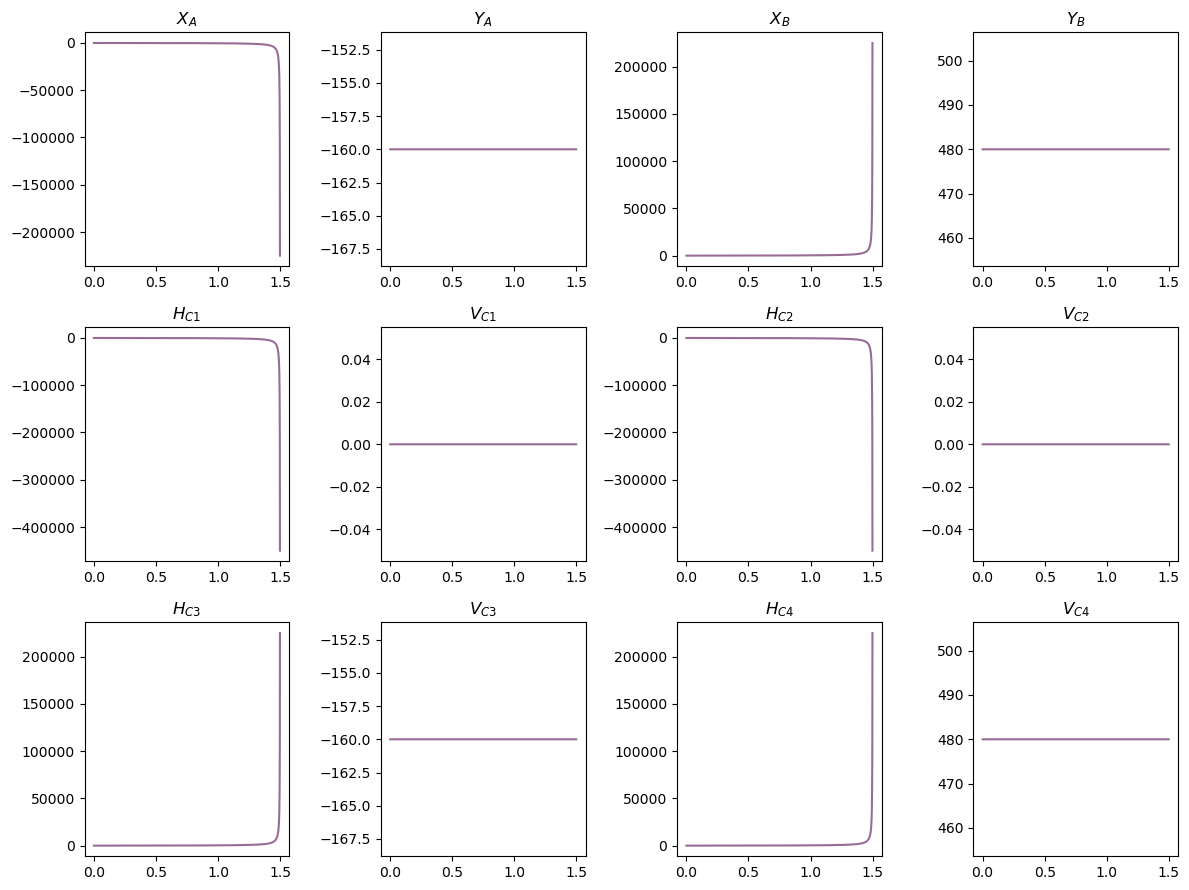

In [39]:
fig, ax = plt.subplots(3, 4, figsize=(12, 9))
ax[0,0].set_title('$X_A$')
ax[0,1].set_title('$Y_A$')
ax[0,2].set_title('$X_B$')
ax[0,3].set_title('$Y_B$')
ax[1,0].set_title('$H_{C1}$')
ax[1,1].set_title('$V_{C1}$')
ax[1,2].set_title('$H_{C2}$')
ax[1,3].set_title('$V_{C2}$')
ax[2,0].set_title('$H_{C3}$')
ax[2,1].set_title('$V_{C3}$')
ax[2,2].set_title('$H_{C4}$')
ax[2,3].set_title('$V_{C4}$')

for i in range(3):
    for j in range(4):
        ax[i,j].plot(h_b, X[(j+(i*4))])

fig.tight_layout();

Iz rezultatov vidmo, da sprememba višine podpore B nima vpliva na vertikalne komponente sil. Drugače je v horizontalni smeri, kjer v zadnjih nekaj milimetrih lahko vidimo izjemen porast rezultatov, ker kaže na nestabilnost sistema.

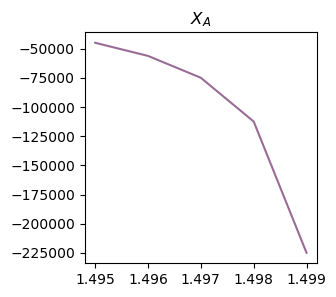

In [40]:
fig, ax = plt.subplots(figsize=(3, 3))
ax.set_title('$X_A$')
ax.plot(h_b[1495:], X[0,1495:]);

### Sprememba sile F

Analizirajmo še, kako se sprememba sile F odraža v sistemu, če se sila spreminja med $20kN \leq F \leq 80kN$. Izračunajmo odziv sistema za vsak kN, če obravnamo konstrukcijo na sliki b).

In [41]:
F = np.linspace(20, 100, 81)
A[8,2] = 4.5

resitve = []
for f in F: 
    b[0] = f
    b[2] = 1.5 * f
    resitve.append(sp.linalg.solve(A, b))

resitve = np.array(resitve)
X = resitve.T

X[:, :5] # prvih pet rešitev

array([[ -40. ,  -42. ,  -44. ,  -46. ,  -48. ],
       [-160. , -160. , -160. , -160. , -160. ],
       [  60. ,   63. ,   66. ,   69. ,   72. ],
       [ 480. ,  480. ,  480. ,  480. ,  480. ],
       [ -90. ,  -94.5,  -99. , -103.5, -108. ],
       [  -0. ,   -0. ,   -0. ,   -0. ,   -0. ],
       [ -90. ,  -94.5,  -99. , -103.5, -108. ],
       [   0. ,    0. ,    0. ,    0. ,    0. ],
       [  30. ,   31.5,   33. ,   34.5,   36. ],
       [-160. , -160. , -160. , -160. , -160. ],
       [  30. ,   31.5,   33. ,   34.5,   36. ],
       [ 480. ,  480. ,  480. ,  480. ,  480. ]])

Rezultati kažejo, da se nekatere reakcije spreminjajo, nekatere pa so od $F$ neodvisne. Potek vrednosti spremenljivk lahko prikažemo v grafu.

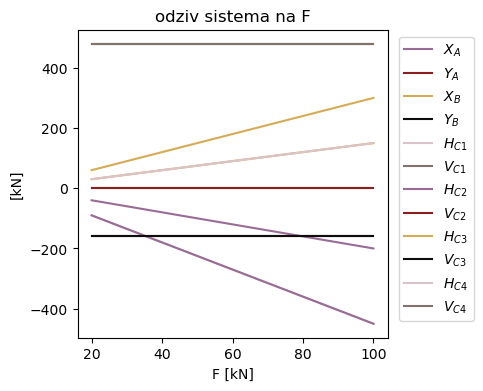

In [42]:
nazivi = ['$X_A$', '$Y_A$', '$X_B$', '$Y_B$', 
          '$H_{C1}$', '$V_{C1}$', '$H_{C2}$','$V_{C2}$', 
          '$H_{C3}$', '$V_{C3}$', '$H_{C4}$', '$V_{C4}$']
fig, ax = plt.subplots(figsize=(4,4))
for i in range(12):
    ax.plot(F, X[i], label=nazivi[i])
ax.set_title('odziv sistema na F')
ax.set_xlabel('F [kN]')
ax.set_ylabel('[kN]')
ax.legend(bbox_to_anchor=(1.3, 1));


### Sprememba obtežbe q

Za konec poglejmo še vpliv zvezne obtežbe $q$ na sistem, če velja ($0kN \leq q \leq 60kN$). Opazujemo kinematično stabilen sistem na sliki b).

In [43]:
q = np.linspace(0, 80, 81)
A[8,2] = 4.5
b[0] = 50
b[2] = 1.5 * 50

resitve = []
for q_i in q:
    b[10] = 4*q_i
    b[11] = 2*4*q_i
    resitve.append(sp.linalg.solve(A, b))

resitve = np.array(resitve)
X = resitve.T

X[:, :5] # prvih pet rešitev (stolpec predstavlja nabor vseh 12 izračunanih vrednosti)

array([[-100., -100., -100., -100., -100.],
       [   0.,   -2.,   -4.,   -6.,   -8.],
       [ 150.,  150.,  150.,  150.,  150.],
       [   0.,    6.,   12.,   18.,   24.],
       [-225., -225., -225., -225., -225.],
       [  -0.,   -0.,   -0.,   -0.,   -0.],
       [-225., -225., -225., -225., -225.],
       [   0.,    0.,    0.,    0.,    0.],
       [  75.,   75.,   75.,   75.,   75.],
       [  -0.,   -2.,   -4.,   -6.,   -8.],
       [  75.,   75.,   75.,   75.,   75.],
       [   0.,    6.,   12.,   18.,   24.]])

Iz grafa vidimo, da obtežba učinkuje na vertikalni komponenti sil v podporah $A$ in $B$ ter členkih $C_3$ in $C_4$.

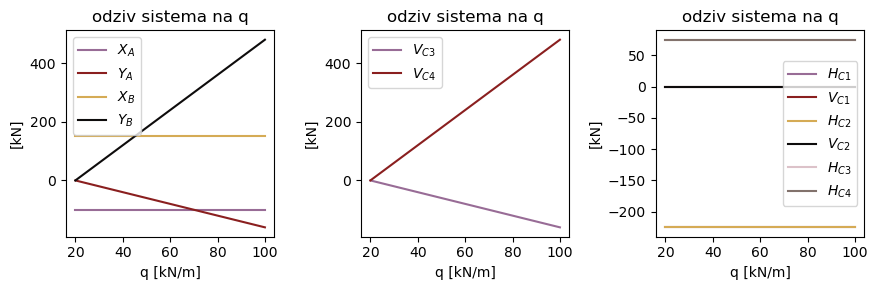

In [44]:
nazivi = ['$X_A$', '$Y_A$', '$X_B$', '$Y_B$', 
          '$H_{C1}$', '$V_{C1}$', '$H_{C2}$','$V_{C2}$', 
          '$H_{C3}$', '$V_{C3}$', '$H_{C4}$', '$V_{C4}$']
fig, ax = plt.subplots(1, 3, figsize=(9,3))
ax0, ax1, ax2 = ax[0], ax[1], ax[2]

for i in range(0,4):
    ax0.plot(F, X[i], label=nazivi[i])
ax0.set_title('odziv sistema na q')
ax0.set_xlabel('q [kN/m]')
ax0.set_ylabel('[kN]')
ax0.legend();

for i in [9, 11]:
    ax1.plot(F, X[i], label=nazivi[i])
ax1.set_title('odziv sistema na q')
ax1.set_xlabel('q [kN/m]')
ax1.set_ylabel('[kN]')
ax1.legend();

for i in [4, 5, 6, 7, 8, 10]:
    ax2.plot(F, X[i], label=nazivi[i])
ax2.set_title('odziv sistema na q')
ax2.set_xlabel('q [kN/m]')
ax2.set_ylabel('[kN]')
ax2.legend()
fig.tight_layout();